In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('data/premier-league-data.csv')

In [4]:
df.head(10)

,home_team,away_team,home_goals,away_goals,result,season
0,Sheffield United,Liverpool,1,1,D,2006-2007
1,Arsenal,Aston Villa,1,1,D,2006-2007
2,Everton,Watford,2,1,H,?
3,Newcastle United,Wigan Athletic,2,1,H,2006-2007
4,Portsmouth,Blackburn Rovers,3,0,H,2006-2007
5,Reading,Middlesbrough,3,2,H,2006-2007
6,West Ham United,Charlton Athletic,3,1,H,2006-2007
7,Bolton Wanderers,Tottenham Hotspur,2,0,H,2006-2007
8,Manchester United,Fulham,5,1,H,?
9,Chelsea,Manchester City,-1,0,H,2006-2007


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4560 entries, 0 to 4559
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   home_team   4560 non-null   object
 1   away_team   4560 non-null   object
 2   home_goals  4560 non-null   int64 
 3   away_goals  4560 non-null   int64 
 4   result      4560 non-null   object
 5   season      4560 non-null   object
dtypes: int64(2), object(4)
memory usage: 213.9+ KB


# INTRODUCTION

The Premier League is the top tier football/soccer competition in England, widely considered to be the most important league in the world.

The objective of this project is to analyze match results from different seasons, but before doing so, we'll need to perform some data cleaning tasks.

> IMPORTANT: This project's activities were designed to be solved in order of occurrence, and the evaluation of each activity depends on the resolution of the previous ones.

#### 1. Replace invalid values from the `season` column

Identify invalid values in the `season` column and replace them with the string `Unknown season` (data imputation).

**IMPORTANT**: If by any reason you think you have incorrectly modified the original dataframe, just go ahead and read it again.

In [9]:
df['season'].notna().sum()

np.int64(4560)

In [18]:
df['season'] = df['season'].str.replace('?', 'Unknown season', regex=False)

In [23]:
df.head(10)

,home_team,away_team,home_goals,away_goals,result,season
0,Sheffield United,Liverpool,1,1,D,2006-2007
1,Arsenal,Aston Villa,1,1,D,2006-2007
2,Everton,Watford,2,1,H,Unknown season
3,Newcastle United,Wigan Athletic,2,1,H,2006-2007
4,Portsmouth,Blackburn Rovers,3,0,H,2006-2007
5,Reading,Middlesbrough,3,2,H,2006-2007
6,West Ham United,Charlton Athletic,3,1,H,2006-2007
7,Bolton Wanderers,Tottenham Hotspur,2,0,H,2006-2007
8,Manchester United,Fulham,5,1,H,Unknown season
9,Chelsea,Manchester City,-1,0,H,2006-2007


In [25]:
df['season'].value_counts()

season
2007-2008         380
2008-2009         380
2009-2010         380
2010-2011         380
2011-2012         380
2012-2013         380
2013-2014         380
2014-2015         380
2015-2016         380
2016-2017         380
2017-2018         380
2006-2007         349
Unknown season     31
Name: count, dtype: int64

#### 2. Identify invalid values in goals scored

Analyze the columns `home_goals` and `away_goals` and answer: how many invalid values each contains?

Hint: Use a visualization to help you in the process!

In [29]:
df['home_goals'].value_counts()

home_goals
 1    1436
 2    1119
 0    1050
 3     568
 4     232
 5      75
 6      30
-2      21
 7      10
-1       9
 8       5
-4       4
 9       1
Name: count, dtype: int64

In [30]:
df['away_goals'].value_counts()

away_goals
 0    1558
 1    1548
 2     862
 3     380
 4     127
 5      32
-2      28
 6      13
-1       6
-4       5
 7       1
Name: count, dtype: int64

<Axes: >

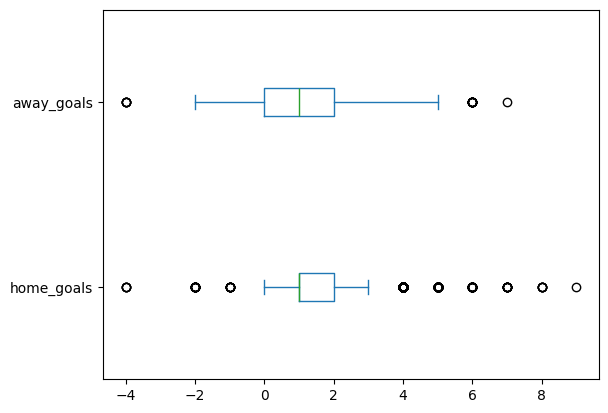

In [42]:
df[['home_goals', 'away_goals']].plot(kind='box', vert=False)

In [40]:
num_negative_home = (df['home_goals'] < 0).sum()
num_negative_home

np.int64(34)

In [41]:
num_negative_away = (df['away_goals'] < 0).sum()
num_negative_away

np.int64(39)

In [ ]:
(df[['home_goals', 'away_goals']] < 0).sum()

home_goals    34
away_goals    39
dtype: int64

#### 3. Replace invalid goals for 0

Replace all the invalid goals in `home_goals` and `away_goals` with 0 (data imputation).

In [51]:
invalid_goals = df[['home_goals', 'away_goals']] < 0
invalid_goals

,home_goals,away_goals
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
4555,False,False
4556,False,False
4557,False,False
4558,False,False


In [57]:
df.loc[df['home_goals'] < 0, 'home_goals'] = 0
df.loc[df['away_goals'] < 0, 'away_goals'] = 0

In [59]:
df['home_goals'].value_counts()

home_goals
1    1436
2    1119
0    1084
3     568
4     232
5      75
6      30
7      10
8       5
9       1
Name: count, dtype: int64

#### 4. Identify and clean invalid results in the `result` column

The `result` column contains a "summary" of the result of the match. `H` indicates a home win; `A` indicates an away win; `D` indicates a draw.

Identify and clean the values assigning the correct result.`

In [60]:
df['result'].value_counts()

result
H    2088
A    1278
D    1151
?      43
Name: count, dtype: int64

In [77]:
df['result'] = df.apply(
  lambda row: 'D' if row['home_goals'] == row['away_goals']
              else 'H' if row['home_goals'] > row['away_goals']
              else 'A',
              axis = 1
)

In [83]:
df['result'].value_counts()

result
H    2107
A    1294
D    1159
Name: count, dtype: int64

In [82]:
df

,home_team,away_team,home_goals,away_goals,result,season
0,Sheffield United,Liverpool,1,1,D,2006-2007
1,Arsenal,Aston Villa,1,1,D,2006-2007
2,Everton,Watford,2,1,H,Unknown season
3,Newcastle United,Wigan Athletic,2,1,H,2006-2007
4,Portsmouth,Blackburn Rovers,3,0,H,2006-2007
...,...,...,...,...,...,...
4555,Newcastle United,Chelsea,3,0,H,2017-2018
4556,Southampton,Manchester City,0,1,A,2017-2018
4557,Swansea City,Stoke City,1,2,A,2017-2018
4558,Tottenham Hotspur,Leicester City,5,4,H,2017-2018


## Analysis
Now that our data is clean, it's time to perform some analysis activities

#### 5. What's the average number of goals per match?

Calculate the average number of goals per match. Enter the value with up to 2 decimals. Example, if you find the value to be `1.8857`, enter just `1.88`.

In [90]:
(df['home_goals'] + df['away_goals']).mean()

np.float64(2.6633771929824563)

#### 6. Create a new column `total_goals`

For the previous activity, it would have been convenient to have a `total_goals` column with the sum of `home_goals` and `away_goals`.

Create the column now.

In [91]:
df['total_goals'] = df['home_goals'] + df['away_goals']

In [92]:
df['total_goals']

0       2
1       2
2       3
3       3
4       3
       ..
4555    3
4556    1
4557    3
4558    9
4559    4
Name: total_goals, Length: 4560, dtype: int64

In [93]:
df

,home_team,away_team,home_goals,away_goals,result,season,total_goals
0,Sheffield United,Liverpool,1,1,D,2006-2007,2
1,Arsenal,Aston Villa,1,1,D,2006-2007,2
2,Everton,Watford,2,1,H,Unknown season,3
3,Newcastle United,Wigan Athletic,2,1,H,2006-2007,3
4,Portsmouth,Blackburn Rovers,3,0,H,2006-2007,3
...,...,...,...,...,...,...,...
4555,Newcastle United,Chelsea,3,0,H,2017-2018,3
4556,Southampton,Manchester City,0,1,A,2017-2018,1
4557,Swansea City,Stoke City,1,2,A,2017-2018,3
4558,Tottenham Hotspur,Leicester City,5,4,H,2017-2018,9


#### 7. Calculate average goals per season

Calculate the number of average goals per season. The result should be a series ordered per season. Store the value in the variable `goals_per_season`. It'll look something like:

In [106]:
goals_per_season = df.groupby('season')['total_goals'].mean().sort_index()

In [107]:
goals_per_season

season
2006-2007         2.429799
2007-2008         2.618421
2008-2009         2.463158
2009-2010         2.747368
2010-2011         2.797368
2011-2012         2.763158
2012-2013         2.773684
2013-2014         2.718421
2014-2015         2.500000
2015-2016         2.676316
2016-2017         2.794737
2017-2018         2.678947
Unknown season    2.419355
Name: total_goals, dtype: float64

#### 8. What's the biggest goal difference in a match?

What was the biggest goal difference in a match found in the dataset?

Note: Goal diff can be either from a home win, or an away win. Example: a `10-1` result or a `1-10` result are the same difference, `9` goals for the winning team.

In [ ]:
(df['home_goals'] - df['away_goals']).max()

np.int64(8)

In [110]:
(df['away_goals'] - df['home_goals']).max()

np.int64(6)

#### 9. What's the team with most away wins?

Find the team that has won the most matches away from home.

In [112]:
df.head()

,home_team,away_team,home_goals,away_goals,result,season,total_goals
0,Sheffield United,Liverpool,1,1,D,2006-2007,2
1,Arsenal,Aston Villa,1,1,D,2006-2007,2
2,Everton,Watford,2,1,H,Unknown season,3
3,Newcastle United,Wigan Athletic,2,1,H,2006-2007,3
4,Portsmouth,Blackburn Rovers,3,0,H,2006-2007,3


In [123]:
df.loc[df['result'] == 'A'].groupby('away_team')['result'].size().sort_values(ascending=False).head(10)

away_team
Chelsea              120
Manchester United    117
Arsenal              103
Liverpool             98
Manchester City       98
Tottenham Hotspur     90
Everton               66
Aston Villa           53
West Ham United       43
Newcastle United      41
Name: result, dtype: int64

#### 10. What's the team with the most goals scored at home?

In [124]:
df.head()

,home_team,away_team,home_goals,away_goals,result,season,total_goals
0,Sheffield United,Liverpool,1,1,D,2006-2007,2
1,Arsenal,Aston Villa,1,1,D,2006-2007,2
2,Everton,Watford,2,1,H,Unknown season,3
3,Newcastle United,Wigan Athletic,2,1,H,2006-2007,3
4,Portsmouth,Blackburn Rovers,3,0,H,2006-2007,3


In [125]:
df.groupby('home_team')['home_goals'].sum().sort_values(ascending=False).head()

home_team
Manchester City      499
Manchester United    495
Chelsea              488
Arsenal              471
Liverpool            459
Name: home_goals, dtype: int64

#### 11. What's the team that received the least amount of goals while playing at home?

This is a tricky activity, because we're not looking for the "total" of goals received, but the "ratio" of received goals / played goals.

Example, the team `Charlton Athletic` is the team with LITERALLY the least goals received at home, with only 20, but that's because they only played 38 matches in total, and only 19 at home.

What's the team with the lowest goals received to match played ratio? Defined as: `goals_received / home_games`.

In [136]:
home_games_per_team = df.groupby('home_team')[['home_team', 'away_goals']].agg({
  'home_team' : 'size',
  'away_goals': 'sum'
}).rename(
  columns={'home_team': 'total_games', 'away_goals': 'goals_recieved'}
).sort_values(['total_games', 'goals_recieved'], ascending=[False, True])

home_games_per_team.head()

,total_games,goals_recieved
home_team,,
Manchester United,228,158
Liverpool,228,180
Arsenal,228,183
Chelsea,228,183
Manchester City,228,186


In [137]:
home_games_per_team['goals_recieved_per_match'] = (
  home_games_per_team['goals_recieved'] / home_games_per_team['total_games']
)

In [138]:
home_games_per_team.sort_values(by='goals_recieved_per_match').head()

,total_games,goals_recieved,goals_recieved_per_match
home_team,,,
Manchester United,228,158,0.692982
Liverpool,228,180,0.789474
Arsenal,228,183,0.802632
Chelsea,228,183,0.802632
Manchester City,228,186,0.815789


#### 12. What's the team with most goals scored playing as a visitor (away from home)?

What's the team that playing away from home scored the most goals?

In [139]:
df.groupby('away_team')['away_goals'].sum().sort_values(ascending=False)

away_team
Arsenal                     379
Manchester United           366
Manchester City             359
Chelsea                     357
Liverpool                   348
Tottenham Hotspur           339
Everton                     255
Aston Villa                 214
West Ham United             209
Newcastle United            177
Sunderland                  170
West Bromwich Albion        154
Stoke City                  150
Fulham                      127
Swansea City                127
Wigan Athletic              125
Southampton                 123
Blackburn Rovers            122
Bolton Wanderers            111
Crystal Palace              103
Leicester City               98
Hull City                    72
Reading                      65
Burnley                      64
Norwich City                 63
Portsmouth                   63
Watford                      62
AFC Bournemouth              60
Wolverhampton Wanderers      56
Queens Park Rangers          55
Birmingham City              5